In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes = True)

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [3]:
#Adding Delivery_status column for classification task
df['Delivery_status'] = df['Delivery_Time_min'].apply(lambda x:'On-time' if x<=30 else 'Late')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Delivery_status
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Late
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,Late
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Late
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Late
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,Late


In [4]:
#Removing Order_ID to reduce noise 
data_clean = df.drop(['Order_ID'],axis = 1)
data_clean

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Delivery_status
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Late
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84,Late
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Late
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Late
4,19.03,Clear,Low,Morning,Bike,16,5.0,68,Late
...,...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54,Late
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71,Late
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81,Late
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55,Late


In [5]:
#Checking for null values
data_clean.isnull().sum()

Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
Delivery_status            0
dtype: int64

In [6]:
df_copy = data_clean.copy(deep=True)

# Categorical → mode
for col in ['Weather','Traffic_Level','Time_of_Day']:
    df_copy[col] = df_copy[col].fillna(df_copy[col].mode()[0])

# Numerical → median
df_copy['Courier_Experience_yrs'] = df_copy['Courier_Experience_yrs'].fillna(
    df_copy['Courier_Experience_yrs'].median()
)

df_copy.isnull().sum()

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
Delivery_status           0
dtype: int64

<AxesSubplot:xlabel='Distance_km', ylabel='Count'>

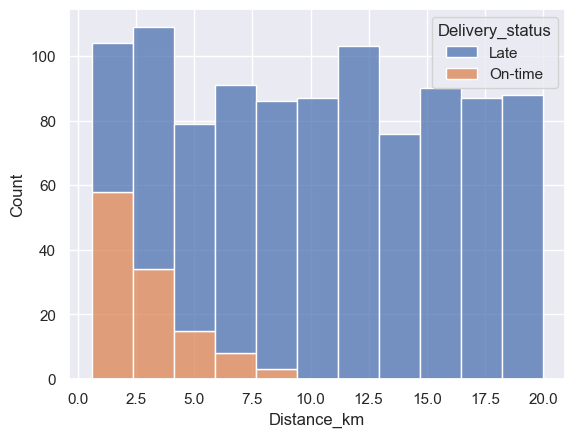

In [7]:
#EDA
sns.histplot(x = 'Distance_km',hue = 'Delivery_status', data = df_copy, multiple = 'stack')

<AxesSubplot:xlabel='Delivery_Time_min', ylabel='Count'>

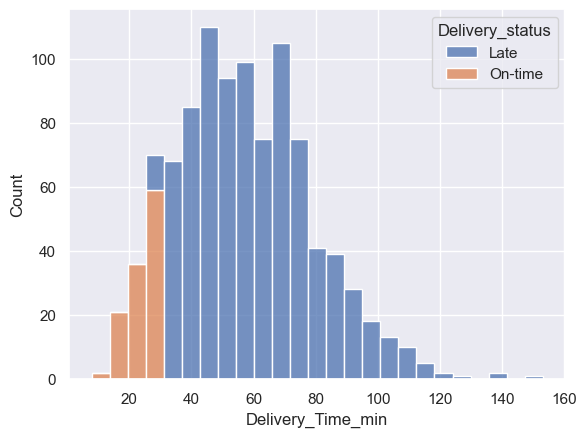

In [8]:
sns.histplot(x='Delivery_Time_min', hue='Delivery_status', data=df_copy, multiple='stack')

<AxesSubplot:xlabel='Weather', ylabel='count'>

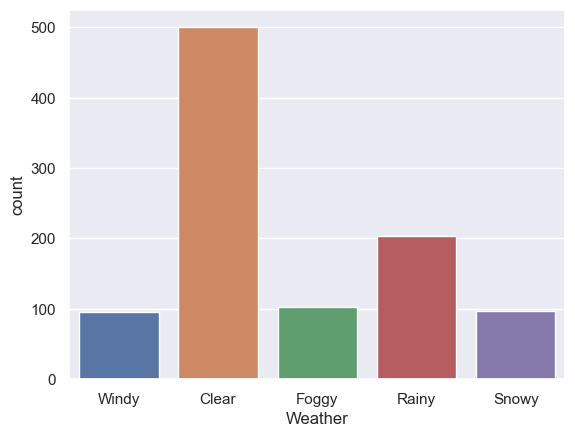

In [9]:
sns.countplot(x = 'Weather', data = df_copy)

<AxesSubplot:xlabel='Traffic_Level', ylabel='count'>

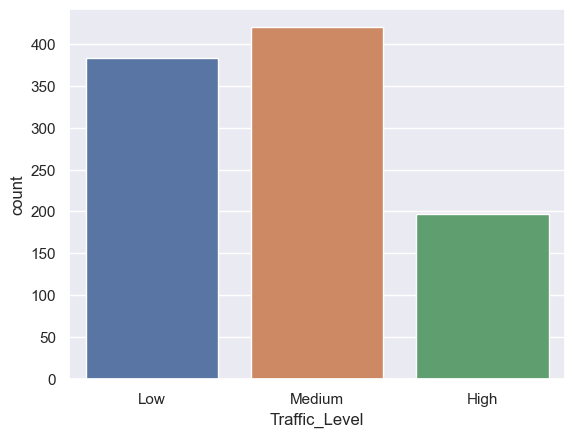

In [10]:
sns.countplot(x='Traffic_Level',data=df_copy)

<AxesSubplot:xlabel='Vehicle_Type', ylabel='count'>

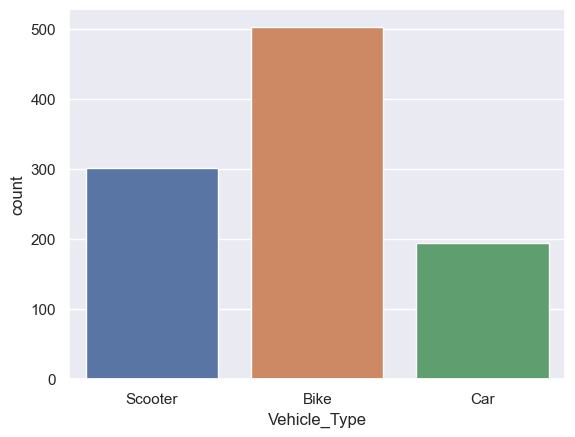

In [11]:
sns.countplot(x='Vehicle_Type',data=df_copy)

<AxesSubplot:xlabel='Distance_km'>

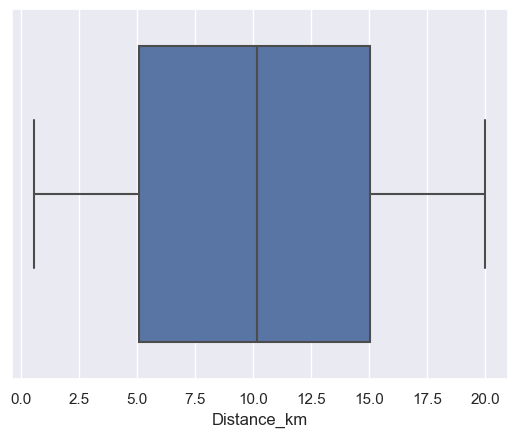

In [12]:
#Boxplot
sns.boxplot(x=df_copy['Distance_km'])

<AxesSubplot:xlabel='Preparation_Time_min'>

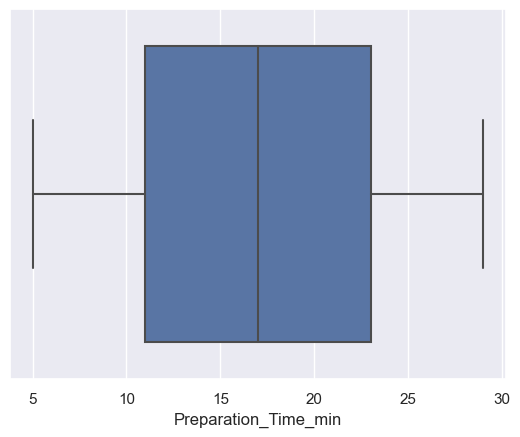

In [13]:
sns.boxplot(x = df_copy['Preparation_Time_min'])

<AxesSubplot:xlabel='Courier_Experience_yrs'>

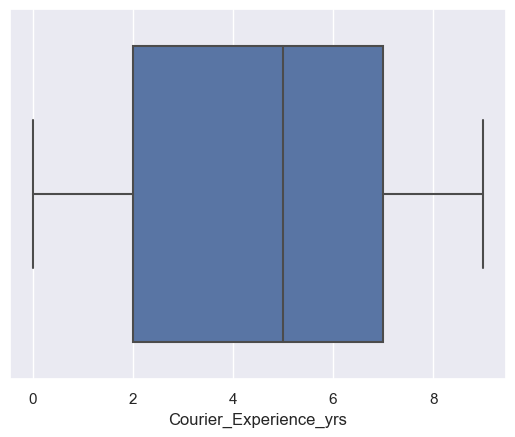

In [14]:
sns.boxplot(x = df_copy['Courier_Experience_yrs'])

<AxesSubplot:xlabel='Delivery_Time_min'>

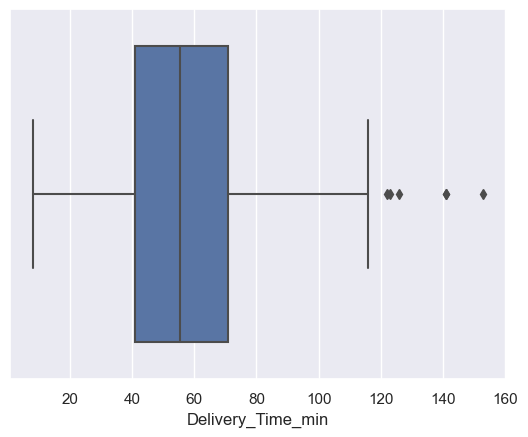

In [15]:
sns.boxplot(x = df_copy['Delivery_Time_min'])

<AxesSubplot:xlabel='Weather', ylabel='Delivery_Time_min'>

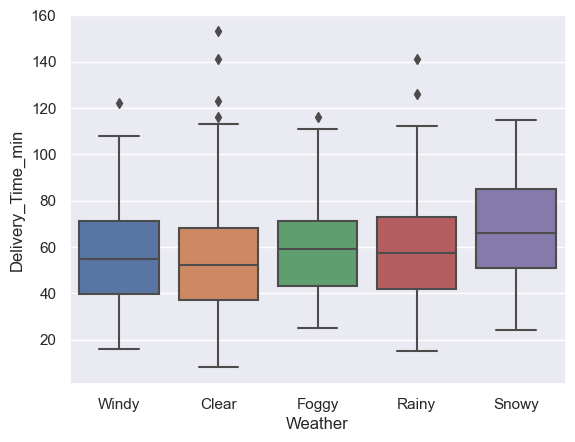

In [16]:
#Boxplt=ot to find relationship and outliers
sns.boxplot(x='Weather', y='Delivery_Time_min', data=df_copy)

<AxesSubplot:xlabel='Traffic_Level', ylabel='Delivery_Time_min'>

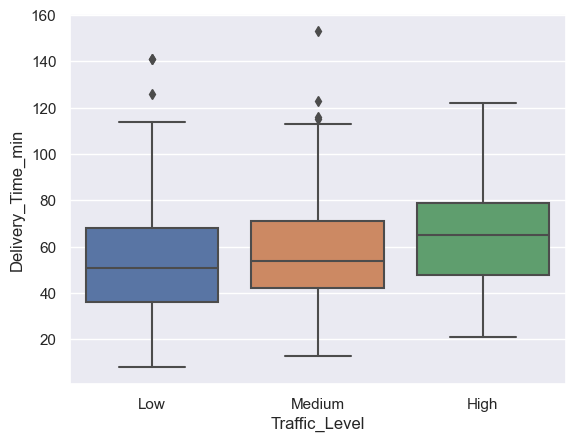

In [17]:
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df_copy)

Late       882
On-time    118
Name: Delivery_status, dtype: int64


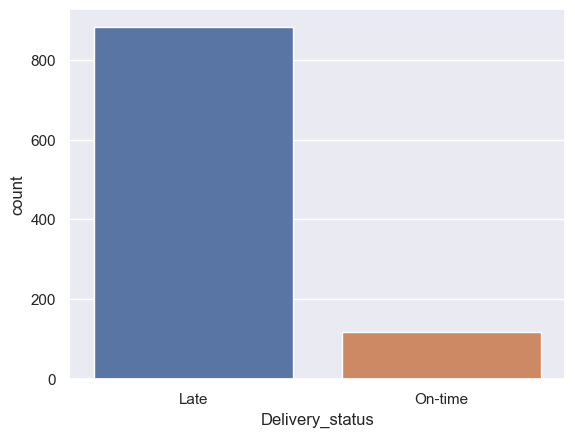

In [18]:
#Checking for imbalance
sns.countplot(x='Delivery_status' , data = df_copy)
print(df_copy.Delivery_status.value_counts())

In [19]:
#Oversampling
from sklearn.utils import resample

df_majority = df_copy[(df_copy['Delivery_status']=='Late')]
df_minority = df_copy[(df_copy['Delivery_status']=='On-time')]

df_oversampled = resample(df_minority, 
                          n_samples = 882,
                          random_state = 0)

df2 = pd.concat([df_oversampled,df_majority])

On-time    882
Late       882
Name: Delivery_status, dtype: int64

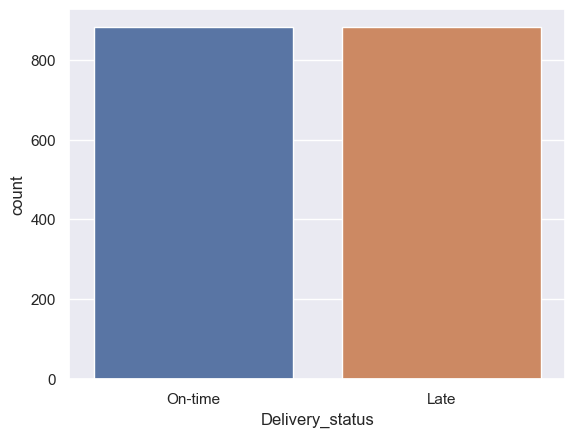

In [20]:
sns.countplot(x = 'Delivery_status', data = df2)
df2.Delivery_status.value_counts()

In [21]:
#Encoding i.e Converting Text to numbers
df2['Weather'].unique()

array(['Rainy', 'Windy', 'Clear', 'Foggy', 'Snowy'], dtype=object)

In [22]:
df2['Traffic_Level'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [23]:
df2['Time_of_Day'].unique()

array(['Evening', 'Afternoon', 'Morning', 'Night'], dtype=object)

In [24]:
df2['Vehicle_Type'].unique()

array(['Scooter', 'Car', 'Bike'], dtype=object)

In [25]:
#One-hot encoding
cat_cols = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
df_encoded = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

df_encoded.head()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Delivery_status,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
330,3.12,14,5.0,28,On-time,0,1,0,0,1,0,1,0,0,0,1
348,2.83,14,6.0,28,On-time,0,0,0,1,0,1,0,0,0,0,1
994,4.37,6,7.0,25,On-time,0,0,0,0,0,1,1,0,0,0,1
516,2.33,6,1.0,17,On-time,0,0,0,0,1,0,0,1,0,1,0
534,3.40,11,6.0,30,On-time,0,0,0,1,0,1,0,1,0,0,0


In [26]:
#Model training

df_encoded.dtypes

Distance_km               float64
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
Delivery_status            object
Weather_Foggy               uint8
Weather_Rainy               uint8
Weather_Snowy               uint8
Weather_Windy               uint8
Traffic_Level_Low           uint8
Traffic_Level_Medium        uint8
Time_of_Day_Evening         uint8
Time_of_Day_Morning         uint8
Time_of_Day_Night           uint8
Vehicle_Type_Car            uint8
Vehicle_Type_Scooter        uint8
dtype: object

In [27]:
y = df_encoded['Delivery_status'].map({'Late':1, 'On-time':0})

X = df_encoded.drop('Delivery_status', axis=1)
X = X.astype(int)

In [28]:
#checking if everything is in numeric or not
X.dtypes

Distance_km               int32
Preparation_Time_min      int32
Courier_Experience_yrs    int32
Delivery_Time_min         int32
Weather_Foggy             int32
Weather_Rainy             int32
Weather_Snowy             int32
Weather_Windy             int32
Traffic_Level_Low         int32
Traffic_Level_Medium      int32
Time_of_Day_Evening       int32
Time_of_Day_Morning       int32
Time_of_Day_Night         int32
Vehicle_Type_Car          int32
Vehicle_Type_Scooter      int32
dtype: object

In [29]:
#Found that there was a data/target leakage.. The model had already knew the ans Bcs of 'Delivery_Time_min..It wasnt predicting..SO..Dropping it

X = X.drop('Delivery_Time_min', axis=1)

In [30]:
y.dtypes

dtype('int64')

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

print(X_train.shape)
print(y_train.shape)

(1411, 14)
(1411,)


In [32]:
#Logistic Regression (Since target is binary classification (Late-0/ On-time-1) so I used LR)

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [33]:
y_pred = lr.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
print(f"Accuracy score: {round(accuracy_score(y_test,y_pred)*100,2)}%\n")
print(f"F1 score: {f1_score(y_test,y_pred)}")
print(f"Precision score: {precision_score(y_test,y_pred)}")
print(f"Recall score: {recall_score(y_test,y_pred)}")

Accuracy score: 97.45%

F1 score: 0.9740634005763689
Precision score: 1.0
Recall score: 0.949438202247191


Text(0.5, 1.0, 'Accuracy score: 97.45%')

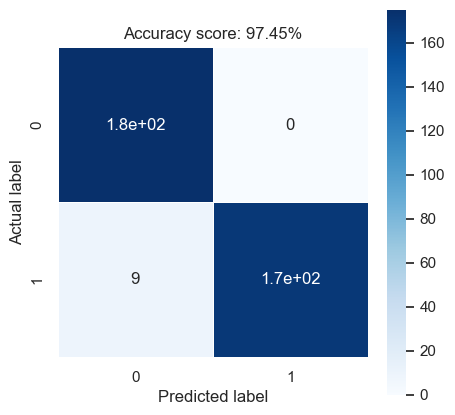

In [35]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidth=.5,square = True,annot = True,cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
all_sample_title = 'Accuracy score: {0}%'.format(round(accuracy_score(y_test,y_pred)*100,2))
plt.title(all_sample_title)

In [36]:
#Till here the projects will the food be delivered on-time or not..
#CLASSIFICATION done........


In [37]:
#Regression



In [38]:
df_encoded['Delivery_status']

330    On-time
348    On-time
994    On-time
516    On-time
534    On-time
        ...   
995       Late
996       Late
997       Late
998       Late
999       Late
Name: Delivery_status, Length: 1764, dtype: object

In [39]:
df_encoded['Delivery_Time_min']

330    28
348    28
994    25
516    17
534    30
       ..
995    54
996    71
997    81
998    55
999    58
Name: Delivery_Time_min, Length: 1764, dtype: int64

In [40]:
y_reg = df2['Delivery_Time_min']

In [41]:
#Dropping Delivery_status bcz the its derived from delivery time..This might cause data leakage
X_reg = df_encoded.drop(['Delivery_Time_min', 'Delivery_status'], axis=1)
X_reg

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
330,3.12,14,5.0,0,1,0,0,1,0,1,0,0,0,1
348,2.83,14,6.0,0,0,0,1,0,1,0,0,0,0,1
994,4.37,6,7.0,0,0,0,0,0,1,1,0,0,0,1
516,2.33,6,1.0,0,0,0,0,1,0,0,1,0,1,0
534,3.40,11,6.0,0,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,13,3.0,0,0,0,0,0,0,1,0,0,1,0
996,16.28,8,9.0,0,1,0,0,1,0,0,1,0,0,1
997,15.62,26,2.0,0,0,1,0,0,0,1,0,0,0,1
998,14.17,8,0.0,0,0,0,0,1,0,0,0,0,0,0


In [42]:
X_reg = X_reg.astype(int)
X_reg

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
330,3,14,5,0,1,0,0,1,0,1,0,0,0,1
348,2,14,6,0,0,0,1,0,1,0,0,0,0,1
994,4,6,7,0,0,0,0,0,1,1,0,0,0,1
516,2,6,1,0,0,0,0,1,0,0,1,0,1,0
534,3,11,6,0,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8,13,3,0,0,0,0,0,0,1,0,0,1,0
996,16,8,9,0,1,0,0,1,0,0,1,0,0,1
997,15,26,2,0,0,1,0,0,0,1,0,0,0,1
998,14,8,0,0,0,0,0,1,0,0,0,0,0,0


In [43]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split( X_reg, y_reg, test_size=0.2, random_state=42)

In [44]:
#Linear Regression model
from sklearn.linear_model import LinearRegression

linR = LinearRegression()
linR.fit(X_train_reg, y_train_reg)

LinearRegression()

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_reg = linR.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

MAE: 4.76350507883314
MSE: 71.00025469224926
R2 Score: 0.8775999666948939


In [ ]:
import pandas as pd

distance = float(input("Enter distance (km): "))
prep_time = float(input("Enter preparation time (min): "))
experience = float(input("Enter courier experience (yrs): "))

weather = input("Enter weather (Foggy/Rainy/Snowy/Windy/Clear): ").strip().lower()
traffic = input("Enter traffic (Low/Medium/High): ").strip().lower()
time_day = input("Enter time of day (Morning/Evening/Night): ").strip().lower()
vehicle = input("Enter vehicle (Car/Scooter/Bike): ").strip().lower()

new_data = pd.DataFrame({
    'Distance_km': [distance],
    'Preparation_Time_min': [prep_time],
    'Courier_Experience_yrs': [experience],

    'Weather_Foggy': [1 if weather == "foggy" else 0],
    'Weather_Rainy': [1 if weather == "rainy" else 0],
    'Weather_Snowy': [1 if weather == "snowy" else 0],
    'Weather_Windy': [1 if weather == "windy" else 0],

    'Traffic_Level_Low': [1 if traffic == "low" else 0],
    'Traffic_Level_Medium': [1 if traffic == "medium" else 0],

    'Time_of_Day_Evening': [1 if time_day == "evening" else 0],
    'Time_of_Day_Morning': [1 if time_day == "morning" else 0],
    'Time_of_Day_Night': [1 if time_day == "night" else 0],

    'Vehicle_Type_Car': [1 if vehicle == "car" else 0],
    'Vehicle_Type_Scooter': [1 if vehicle == "scooter" else 0]
})

predicted_time = linR.predict(new_data)[0]

print("Predicted Delivery Time:", round(predicted_time, 2), "minutes")

if predicted_time <= 30:
    print("Delivery Status: On-time")
else:
    print("Delivery Status: Late")

Enter distance (km):  5
Enter preparation time (min):  5
Enter courier experience (yrs):  3
Enter weather (Foggy/Rainy/Snowy/Windy/Clear):  clear
Enter traffic (Low/Medium/High):  low
Enter time of day (Morning/Evening/Night):  night
Enter vehicle (Car/Scooter/Bike):  bike
Predicted Delivery Time: 23.24 minutes
Delivery Status: On-time
